In [5]:
# Import our cleaning function
from wrangle import clean_files
from sklearn.model_selection import train_test_split
import pandas as pd
import numpy as np

# Load data
df = clean_files("./data/buenos-aires-real-estate-*.csv")   # <--- "./data/buenos-aires-real-estate-*.csv"

# Define target and features
target = "price_aprox_usd"
feature = [col for col in df.columns if col not in target]

# Split into features and target
X = df[feature] #<--- feature matrix
y = df[target] # <--- target vector

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")

Features shape: (6247, 4)
Target shape: (6247,)


In [6]:
X_train_4, X_test_4, y_train_4, y_test_4 = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training rows: {len(X_train_4)}")
print(f"Testing rows: {len(X_test_4)}")

Training rows: 4997
Testing rows: 1250


In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LinearRegression, Ridge, RidgeCV, Lasso, LassoCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import root_mean_squared_error, mean_absolute_error, r2_score
from category_encoders import OneHotEncoder


In [8]:
def get_rmse_4(model, X, y_true):
    """
    Calculate RMSE for a given model and dataset.

    Parameters:
    -----------
    model : fitted sklearn model or pipeline
    X : features (DataFrame or array)
    y_true : true target values

    Returns:
    --------
    float : RMSE value
    """
    y_pred = model.predict(X)  # <--- X
    rmse = root_mean_squared_error(y_true, y_pred) # <--- y_true, y_pred
    return rmse

# Test the function
print("Function created successfully!")

Function created successfully!


In [9]:
# Calculate mean
y_mean_4 = y_train_4.mean()

# Create baseline predictions
y_pred_baseline_train = [y_mean_4] * len(y_train_4)
y_pred_baseline_test = [y_mean_4] * len(y_test_4)

# Calculate RMSE
rmse_base_train = root_mean_squared_error(y_train_4, y_pred_baseline_train)  # root_mean_squared_error(y_train_4, y_pred_baseline_train)
rmse_base_test = root_mean_squared_error(y_test_4, y_pred_baseline_test)  # root_mean_squared_error(y_test_4, y_pred_baseline_test)

print(f"Baseline Train RMSE: ${rmse_base_train:,.2f}")
print(f"Baseline Test RMSE: ${rmse_base_test:,.2f}")

Baseline Train RMSE: $59,700.25
Baseline Test RMSE: $57,576.13


In [10]:
model_linear_4 = make_pipeline(
    OneHotEncoder(use_cat_names=True),
    StandardScaler(),
    LinearRegression()
)

model_linear_4.fit(X_train_4, y_train_4)  # X_train_4, y_train_4

rmse_linear_train = get_rmse_4(model_linear_4, X_train_4, y_train_4)  # model_linear_4, X_train_4, y_train_4
rmse_linear_test = get_rmse_4(model_linear_4, X_test_4, y_test_4)  # model_linear_4, X_test_4, y_test_4

print(f"Linear Regression Train RMSE: ${rmse_linear_train:,.2f}")
print(f"Linear Regression Test RMSE: ${rmse_linear_test:,.2f}")

Linear Regression Train RMSE: $34,200.43
Linear Regression Test RMSE: $33,088.37


In [11]:
model_ridge_4 = make_pipeline(
    OneHotEncoder(use_cat_names=...),  # True
    StandardScaler(),
    RidgeCV(alphas=np.logspace(-2, 4, 100))  # np.logspace(-2, 4, 100)
)

model_ridge_4.fit(X_train_4, y_train_4)  # X_train_4, y_train_4

rmse_ridge_train = get_rmse_4(model_ridge_4, X_train_4, y_train_4)  # model_ridge_4, X_train_4, y_train_4
rmse_ridge_test = get_rmse_4(model_ridge_4, X_test_4, y_test_4)  # model_ridge_4, X_test_4, y_test_4

# Extract the tuned alpha value
alpha_ridge_chosen = model_ridge_4.named_steps["ridgecv"].alpha_
print(f"Best Ridge alpha: {alpha_ridge_chosen:.6f}")
print(f"Ridge Train RMSE: ${rmse_ridge_train:,.2f}")
print(f"Ridge Test RMSE: ${rmse_ridge_test:,.2f}")

Best Ridge alpha: 43.287613
Ridge Train RMSE: $34,203.95
Ridge Test RMSE: $33,071.27


In [12]:
model_lasso_4 = make_pipeline(
    OneHotEncoder(use_cat_names=True),  # True
    StandardScaler(),
    LassoCV(alphas=np.logspace(-4, 2, 100), max_iter=10000)  # np.logspace(-4, 2, 100)
)

model_lasso_4.fit(X_train_4, y_train_4)  # X_train_4, y_train_4

rmse_lasso_train = get_rmse_4(model_lasso_4, X_train_4, y_train_4)  # model_lasso_4, X_train_4, y_train_4
rmse_lasso_test = get_rmse_4(model_lasso_4, X_test_4, y_test_4)  # model_lasso_4, X_test_4, y_test_4

# Extract the tuned alpha value
alpha_lasso_chosen = model_lasso_4.named_steps["lassocv"].alpha_
print(f"Best Lasso alpha: {alpha_lasso_chosen:.6f}")
print(f"Lasso Train RMSE: ${rmse_lasso_train:,.2f}")
print(f"Lasso Test RMSE: ${rmse_lasso_test:,.2f}")

Best Lasso alpha: 32.745492
Lasso Train RMSE: $34,203.20
Lasso Test RMSE: $33,069.18


In [13]:
# Build Results Table
data_4 = {
    "Model": ["Baseline", "Linear Regression", "Ridge (CV-tuned)", "Lasso (CV-tuned)"],
    "Train_RMSE": [
        rmse_base_train,
        rmse_linear_train,# rmse_linear_train
        rmse_ridge_train,  # rmse_ridge_train
        rmse_lasso_train   # rmse_lasso_train
    ],
    "Test_RMSE": [
        rmse_base_test,
        rmse_linear_test,  # rmse_linear_test
        rmse_linear_test,  # rmse_ridge_test
        rmse_lasso_test   # rmse_lasso_test
    ]
}

df_results_4 = pd.DataFrame(data_4)

# Calculate Generalization Gap
df_results_4["Gap"] = df_results_4["Test_RMSE"] - df_results_4["Train_RMSE"]

# Set Model as index for better display
df_results_4 = df_results_4.set_index("Model")

print("\n" + "="*60)
print("MODEL COMPARISON TABLE")
print("="*60)
print(df_results_4.round(2))
print("="*60)


MODEL COMPARISON TABLE
                   Train_RMSE  Test_RMSE      Gap
Model                                            
Baseline             59700.25   57576.13 -2124.12
Linear Regression    34200.43   33088.37 -1112.06
Ridge (CV-tuned)     34203.95   33088.37 -1115.58
Lasso (CV-tuned)     34203.20   33069.18 -1134.01


In [14]:
# Build Results Table
data_4 = {
    "Model": ["Baseline", "Linear Regression", "Ridge (CV-tuned)", "Lasso (CV-tuned)"],
    "Train_RMSE": [
        rmse_base_train,
        rmse_linear_train,# rmse_linear_train
        rmse_ridge_train,  # rmse_ridge_train
        rmse_lasso_train   # rmse_lasso_train
    ],
    "Test_RMSE": [
        rmse_base_test,
        rmse_linear_test,  # rmse_linear_test
        rmse_linear_test,  # rmse_ridge_test
        rmse_lasso_test   # rmse_lasso_test
    ]
}

df_results_4 = pd.DataFrame(data_4)

# Calculate Generalization Gap
df_results_4["Gap"] = df_results_4["Test_RMSE"] - df_results_4["Train_RMSE"]

# Set Model as index for better display
df_results_4 = df_results_4.set_index("Model")

print("\n" + "="*60)
print("MODEL COMPARISON TABLE")
print("="*60)
print(df_results_4.round(2))
print("="*60)


MODEL COMPARISON TABLE
                   Train_RMSE  Test_RMSE      Gap
Model                                            
Baseline             59700.25   57576.13 -2124.12
Linear Regression    34200.43   33088.37 -1112.06
Ridge (CV-tuned)     34203.95   33088.37 -1115.58
Lasso (CV-tuned)     34203.20   33069.18 -1134.01


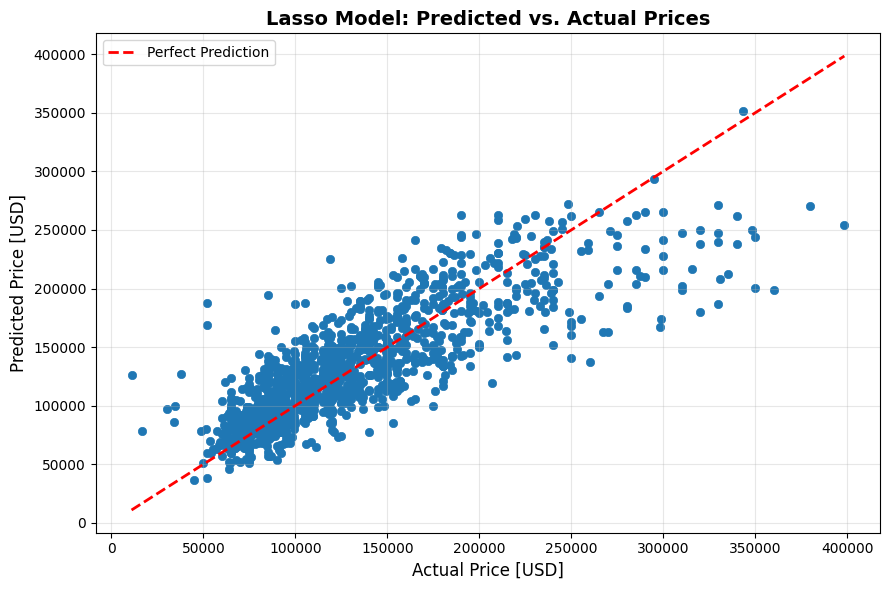

In [15]:
y_pred_lasso_4 = model_lasso_4.predict(X_test_4)

fig, ax = plt.subplots(figsize=(9, 6))
ax.scatter(y_test_4, y_pred_lasso_4, linewidth=0.5)

ideal_line = np.linspace(y_test_4.min(), y_test_4.max(), 100)
ax.plot(ideal_line, ideal_line, color="red", linestyle="--", linewidth=2, label="Perfect Prediction")

ax.set_xlabel("Actual Price [USD]", fontsize=12)
ax.set_ylabel("Predicted Price [USD]", fontsize=12)
ax.set_title("Lasso Model: Predicted vs. Actual Prices", fontsize=14, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

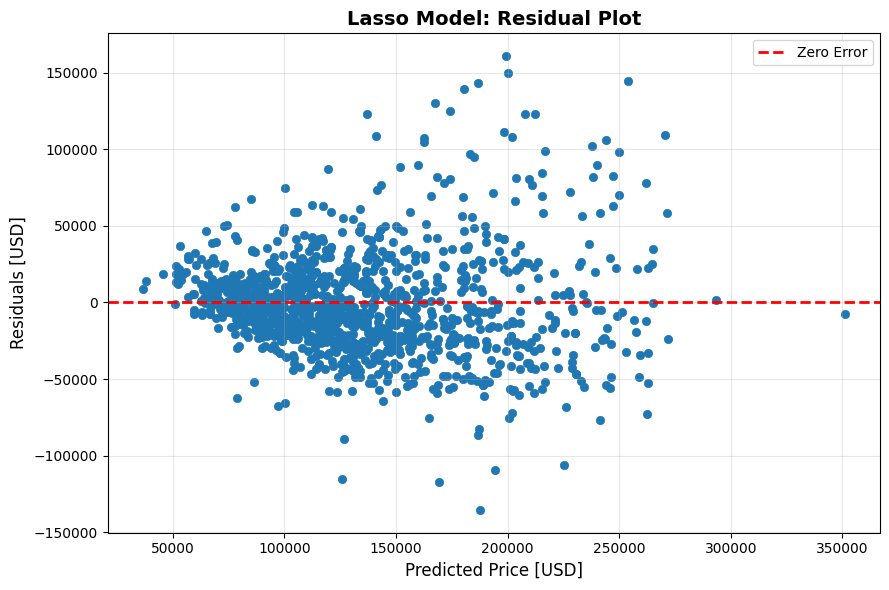

In [16]:
residuals_4 = y_test_4 - y_pred_lasso_4

fig_res, ax_res = plt.subplots(figsize=(9, 6))
ax_res.scatter(y_pred_lasso_4, residuals_4, linewidth=0.5)
ax_res.axhline(y=0, color='r', linestyle='--', linewidth=2, label='Zero Error')
ax_res.set_xlabel("Predicted Price [USD]", fontsize=12)
ax_res.set_ylabel("Residuals [USD]", fontsize=12)
ax_res.set_title("Lasso Model: Residual Plot", fontsize=14, fontweight='bold')
ax_res.legend(fontsize=10)
ax_res.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [17]:
# Extract from pipeline
coefs_4 = model_lasso_4.named_steps["lassocv"].coef_ # .coef_
feature_names_4 = model_lasso_4.named_steps["onehotencoder"].get_feature_names_out() # .get_feature_names_out()

feat_imp_4 = pd.Series(coefs_4, index=feature_names_4)  # coefs_4, index=feature_names_4

print(f"Total features: {len(feat_imp_4)}")
print(f"Non-zero features: {(feat_imp_4 != 0).sum()}")
print("\nTop 5 positive coefficients:")
print(feat_imp_4.nlargest(5))
print("\nTop 5 negative coefficients:")
print(feat_imp_4.nsmallest(5))

Total features: 59
Non-zero features: 58

Top 5 positive coefficients:
surface_covered_in_m2         40346.180348
neighborhood_Puerto Madero     9793.898166
neighborhood_Palermo           9684.053726
lat                            8837.497355
neighborhood_Belgrano          7270.101180
dtype: float64

Top 5 negative coefficients:
neighborhood_Balvanera      -5420.759156
neighborhood_Boca           -4734.035389
neighborhood_Once           -4527.997089
neighborhood_Congreso       -3353.222368
neighborhood_Constitución   -2736.586612
dtype: float64


In [18]:
zero_features_4 = (feat_imp_4 == 0).sum()  # (feat_imp_4 == 0).sum()
total_features_4 = len(feat_imp_4)
percent_eliminated_4 = (zero_features_4 / total_features_4) * 100

print(f"Lasso eliminated {zero_features_4} out of {total_features_4} features.")
print(f"Percentage eliminated: {percent_eliminated_4:.1f}%")

Lasso eliminated 1 out of 59 features.
Percentage eliminated: 1.7%


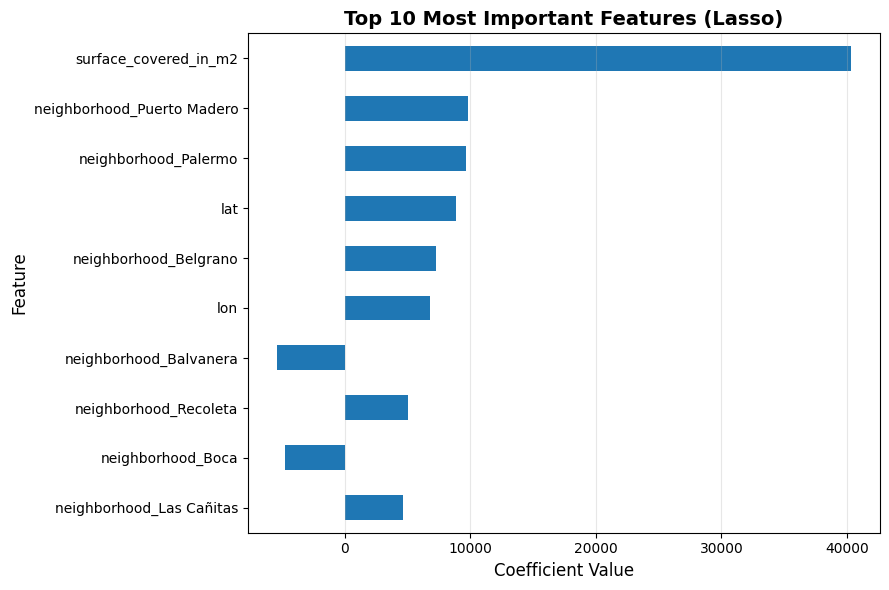

In [19]:
fig_feat, ax_feat = plt.subplots(figsize=(9, 6))
feat_imp_4.sort_values(key=abs).tail(10).plot(kind="barh", ax=ax_feat)
ax_feat.set_title("Top 10 Most Important Features (Lasso)", fontsize=14, fontweight='bold')
ax_feat.set_xlabel("Coefficient Value", fontsize=12)
ax_feat.set_ylabel("Feature", fontsize=12)
ax_feat.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

In [22]:
top_feature_4 = feat_imp_4.idxmax()
top_coefficient_4 = feat_imp_4.max()

print(f"The most influential positive feature is: {top_feature_4}")
print(f"Its coefficient is: ${top_coefficient_4:,.2f}")

The most influential positive feature is: surface_covered_in_m2
Its coefficient is: $40,346.18


In [33]:

recommendation = f"""
=================================================================
FINAL MODEL SELECTION REPORT
=================================================================

EXECUTIVE SUMMARY:
Based on comprehensive evaluation, I recommend the {best_model} model
for production deployment.

PERFORMANCE COMPARISON:
- Baseline Test RMSE: ${rmse_base_test:,.2f}
- Linear Regression Test RMSE: ${rmse_linear_test:,.2f}
- Ridge (CV-tuned) Test RMSE: ${rmse_ridge_test:,.2f}
- Lasso (CV-tuned) Test RMSE: ${rmse_lasso_test:,.2f}

GENERALIZATION ANALYSIS:
The best model shows the best balance between low test error
and minimal generalization gap, indicating it will perform
reliably on new, unseen properties.

INTERPRETABILITY:
The Lasso model eliminated {zero_features_4} out of
{total_features_4} features ({percent_eliminated_4:.1f}%),
making it highly interpretable for business stakeholders.

KEY PREDICTORS:
The most influential feature is: {top_feature_4}

RECOMMENDATION:
I recommend deploying the {best_model} model because:
1. It achieved the lowest RSME of{results_df['test_RSME'].min():.2f}, indicating best perfomance.
2. It shows a good generalization with a small gap between train and test RSME.
3. For interpretability, {top_feature_4} is the strongest driver of price, which aligns with real estate intuition.

=================================================================
"""

print(recommendation)

NameError: name 'best_model' is not defined